# 8.1 Sigma Sweep Full Run
Note that this was done at seed = 0 instead of five different seeds.   
Will create 8.2 eventually so all five different seeds can be run

## Import modules

In [1]:
import sys
sys.path.insert(0, "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation")

from sigma_sweep import rho_for_run

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)


## Create simulated data and train models
Six sigmas at 0.1, 0.5, 1.0, 2.0, 5.0, and 10.0

Epoch 134 (batch 24/24) | | train elbo: 76.51 (last epoch: 76.13) | val ll: 85.39:  13%|█▎        | 134/1000 [00:37<04:02,  3.58it/s]2026-07-17 08:59:14,756 | INFO : Early stopping has been triggered.
2026-07-17 08:59:14,758 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-17 08:59:14,758 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-17 08:59:14,759 | INFO : Saving decipher model with run_id 2026-07-17-08-59-14-frozen-champagne-matrix.


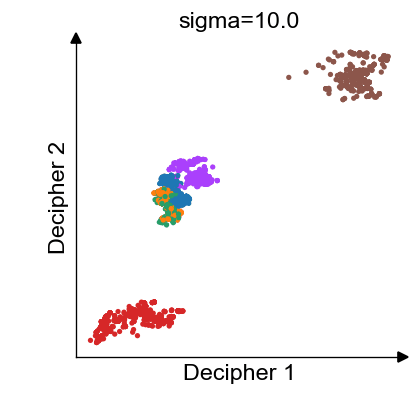

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-17 08:59:15,054 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-17 08:59:15,054 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-17 08:59:15,082 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-17 08:59:15,268 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simula

,model,sigma,seed,rho,ground_truth_h5ad,trained_h5ad
0,Decipher-BC,0.1,0,0.933128,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
1,Decipher-BC,0.5,0,0.937616,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
2,Decipher-BC,1.0,0,0.936888,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
3,Decipher-BC,2.0,0,0.934307,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
4,Decipher-BC,5.0,0,0.918306,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
5,Decipher-BC,10.0,0,0.566909,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
6,Base Decipher,0.1,0,0.940194,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
7,Base Decipher,0.5,0,0.935922,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
8,Base Decipher,1.0,0,0.534894,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...
9,Base Decipher,2.0,0,0.840021,/Users/alanxie/CodingProjects/Columbia/Azizi L...,/Users/alanxie/CodingProjects/Columbia/Azizi L...


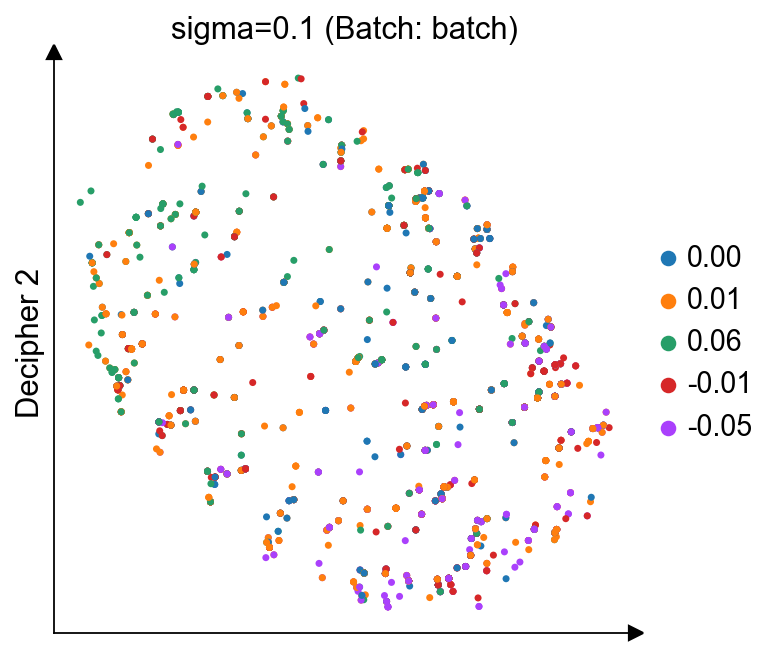

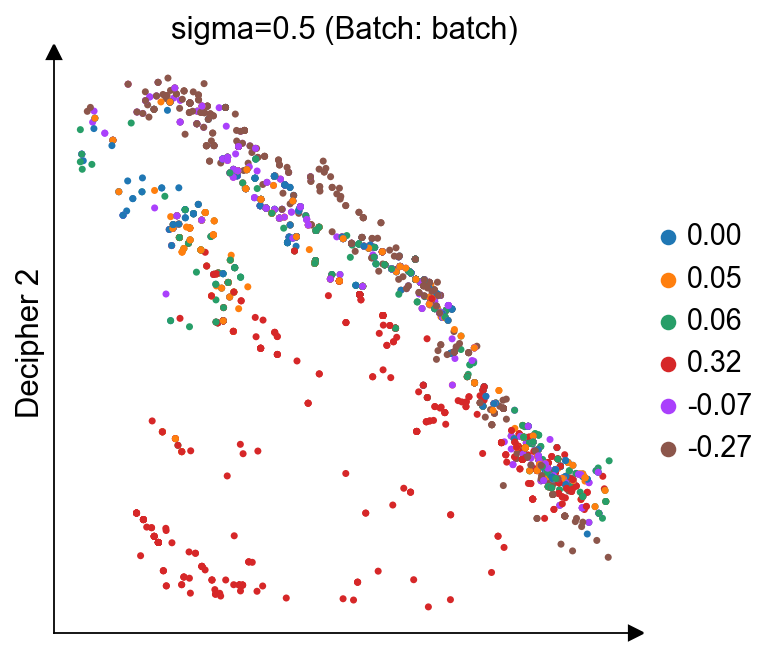

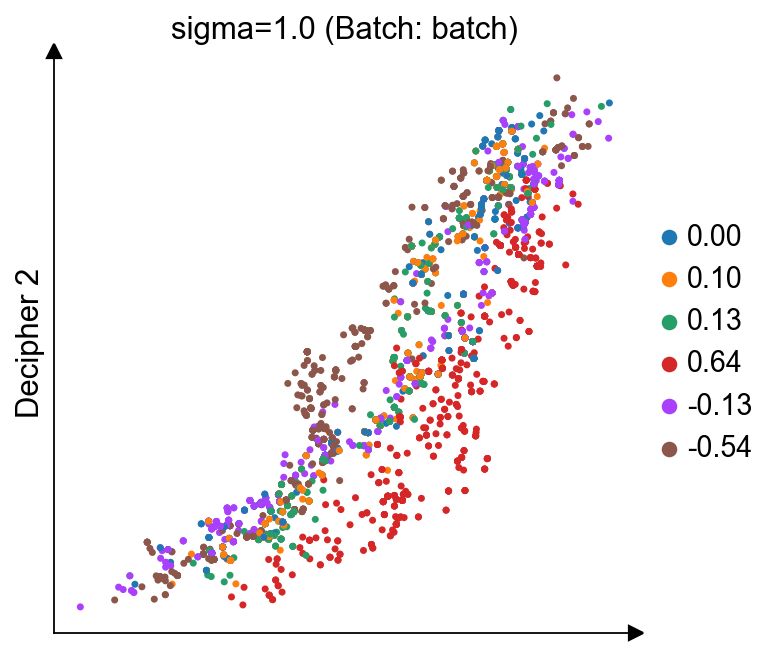

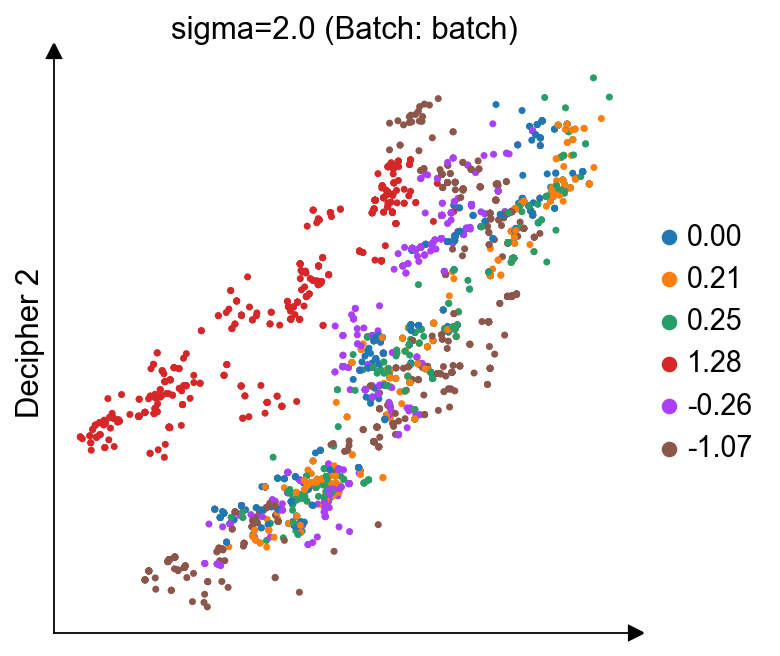

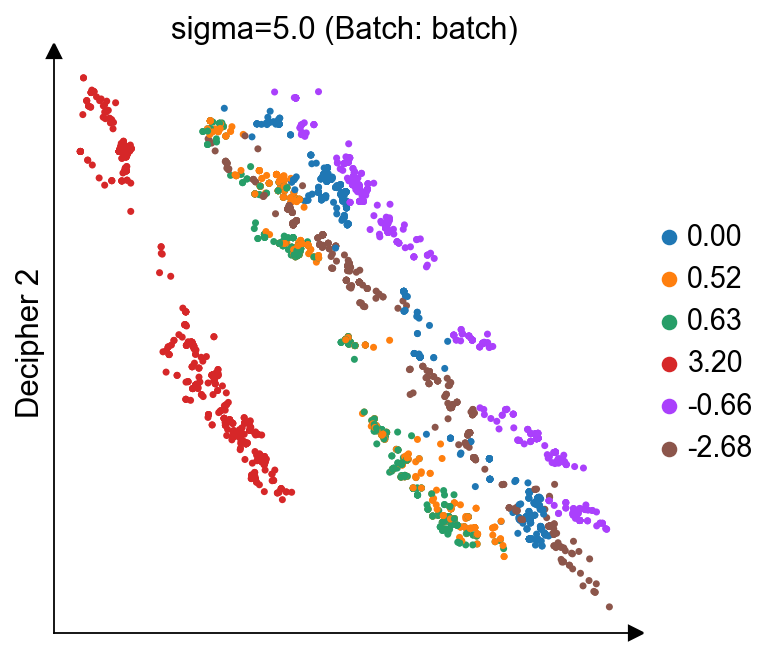

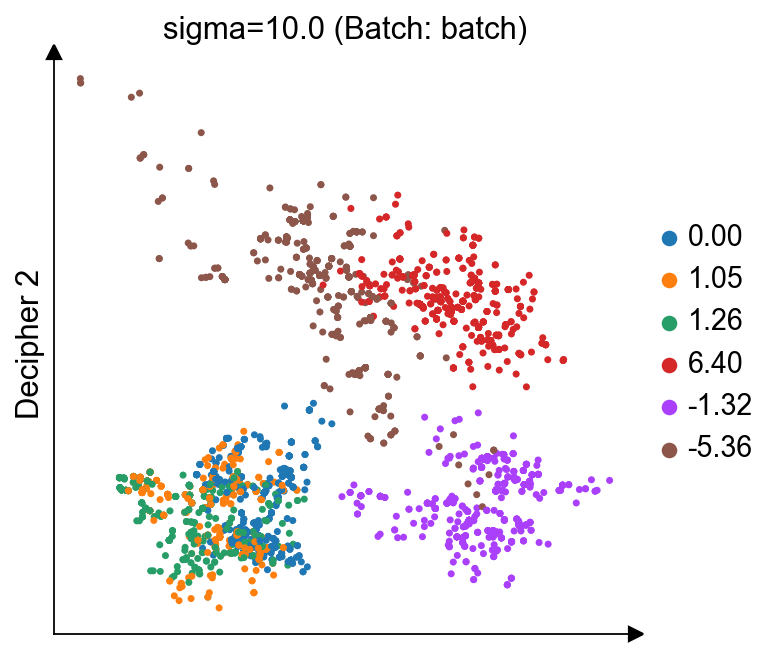

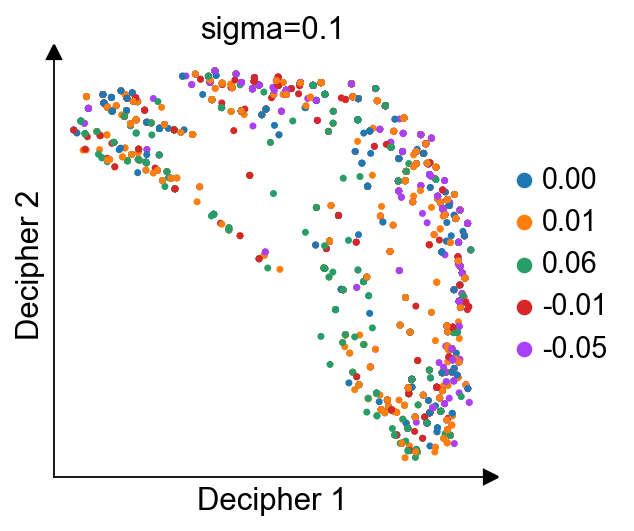

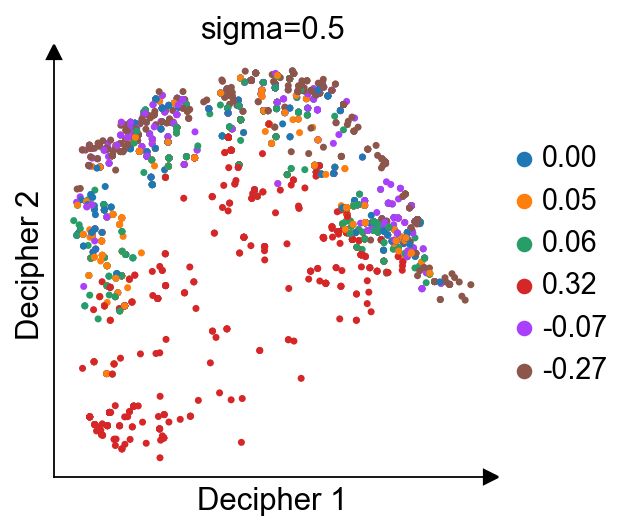

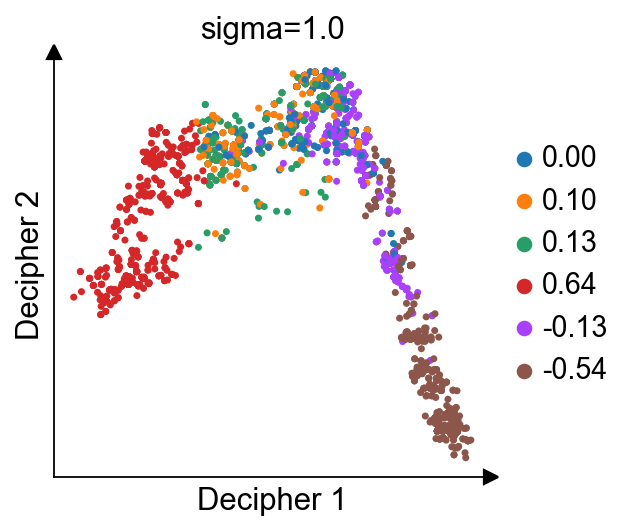

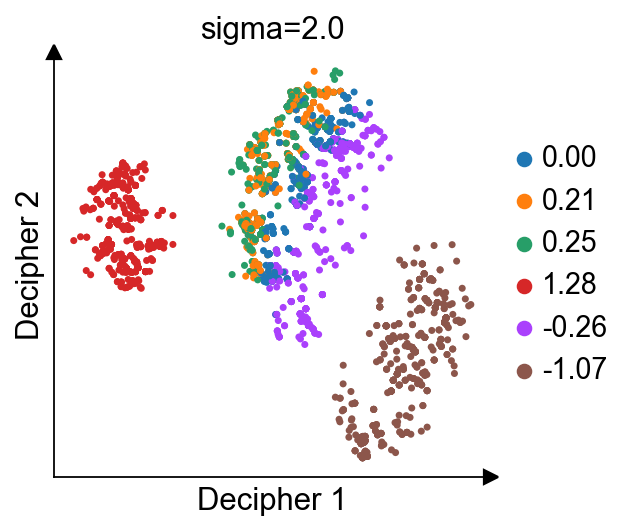

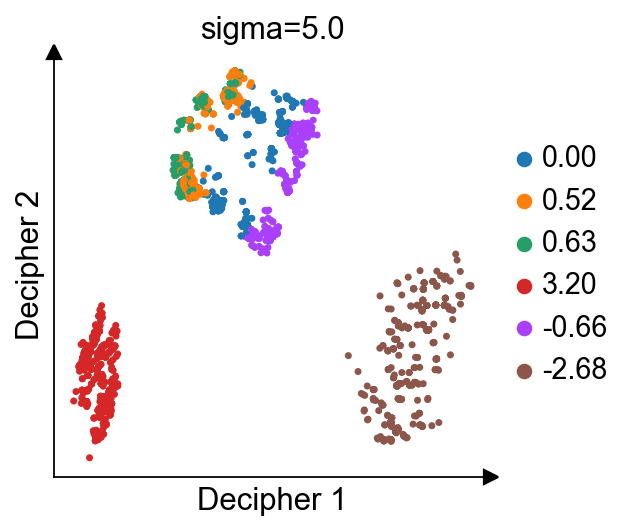

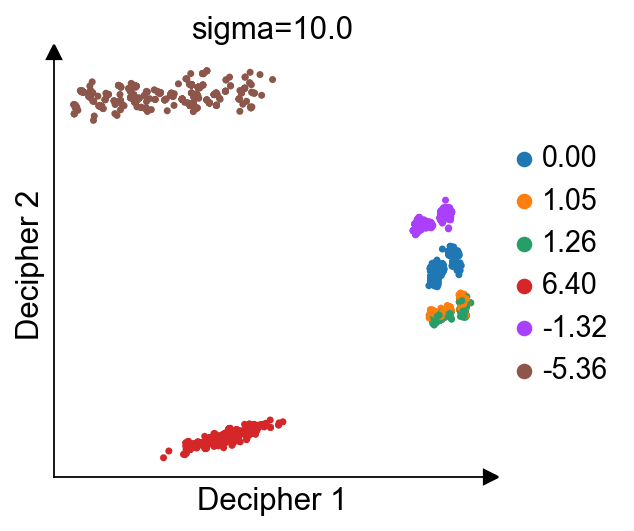

In [2]:
import os
import pandas as pd

results_dir = "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Adata/v-to-z/trained"
os.makedirs(results_dir, exist_ok=True)

sigmas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
seeds_phase1 = [0]

records = []
for batch_aware, model_name in [(True, "Decipher-BC"), (False, "Base Decipher")]:
    for sigma in sigmas:
        for seed in seeds_phase1:
            try:
                rho, gt_path, trained_path, adata = rho_for_run(sigma=sigma, seed=seed, batch_aware=batch_aware)
            except Exception as e:
                print(f"[{model_name}] sigma={sigma} seed={seed} failed: {type(e).__name__}: {e}")
                continue
            records.append({
                "model": model_name,
                "sigma": sigma,
                "seed": seed,
                "rho": rho,
                "ground_truth_h5ad": gt_path,
                "trained_h5ad": trained_path,
            })

results_df = pd.DataFrame(records)
results_df.to_csv(os.path.join(results_dir, "sigma_sweep_results_phase1.csv"), index=False)
results_df

2026-07-17 09:07:00,298 | INFO : Substituting symbol N from STIXNonUnicode
2026-07-17 09:07:00,317 | INFO : Substituting symbol N from STIXNonUnicode
2026-07-17 09:07:00,339 | INFO : Substituting symbol N from STIXNonUnicode


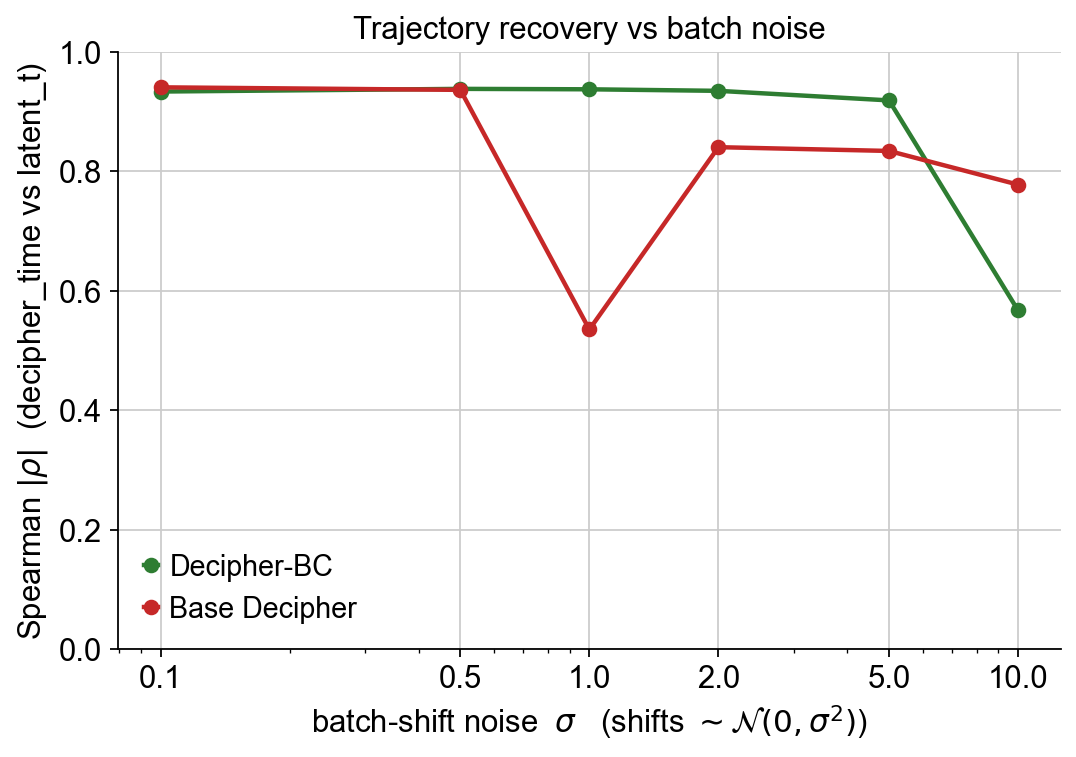

In [4]:
import numpy as np
import matplotlib.pyplot as plt

colors = {"Decipher-BC": "#2E7D32", "Base Decipher": "#C62828"}

fig, ax = plt.subplots(figsize=(7, 5))
for name in ["Decipher-BC", "Base Decipher"]:
    sub = results_df[results_df["model"] == name]
    grouped = sub.groupby("sigma")["rho"]
    mean = grouped.mean().reindex(sigmas)
    sd_ = grouped.std().reindex(sigmas)
    ax.plot(sigmas, mean, marker="o", color=colors[name], label=name, linewidth=2)
    ax.fill_between(sigmas, mean - sd_, mean + sd_, color=colors[name], alpha=0.18)

ax.set_xscale("log")
ax.set_xticks(sigmas)
ax.set_xticklabels([str(s) for s in sigmas])
ax.set_xlabel(r"batch-shift noise  $\sigma$   (shifts $\sim \mathcal{N}(0,\sigma^2)$)")
ax.set_ylabel(r"Spearman $|\rho|$  (decipher_time vs latent_t)")
ax.set_title("Trajectory recovery vs batch noise")
ax.set_ylim(0, 1); ax.axhline(0, color="0.8", lw=0.8)
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


### Analysis
We see here that Decipher-BC outperforms base Decipher in terms of Spearman's correlation/rho.   

It should be noted that there is a sharp drop at 1.0 for Base Decipher, but there's a recovery at 2.0. This is likely an anomaly, and could be smoothed out if we run this at five different seeds.   

For the next steps, we can pick the following sigmas 
- 0.1, to compare base
- 1.0, to investigate the sharp drop in Base Decipher
- 5.0, a "mid-range" dip
- 10.0, the final sigma

and plot learned vs latent pseudotime and learned vs learned vs latent z space

Below, we start by importing relevant modules and defining a function for loading the .h5ad file

In [9]:
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

def load_run(results_df, sigma, model_name):
    row = results_df[(results_df["sigma"] == sigma) & (results_df["model"] == model_name)].iloc[0]
    return row, sc.read_h5ad(row["trained_h5ad"])


## Plots for Sigma = 0.1
Specifically, we look at
- Learned vs latent pseudotime
- Learned vs latent ground truth

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


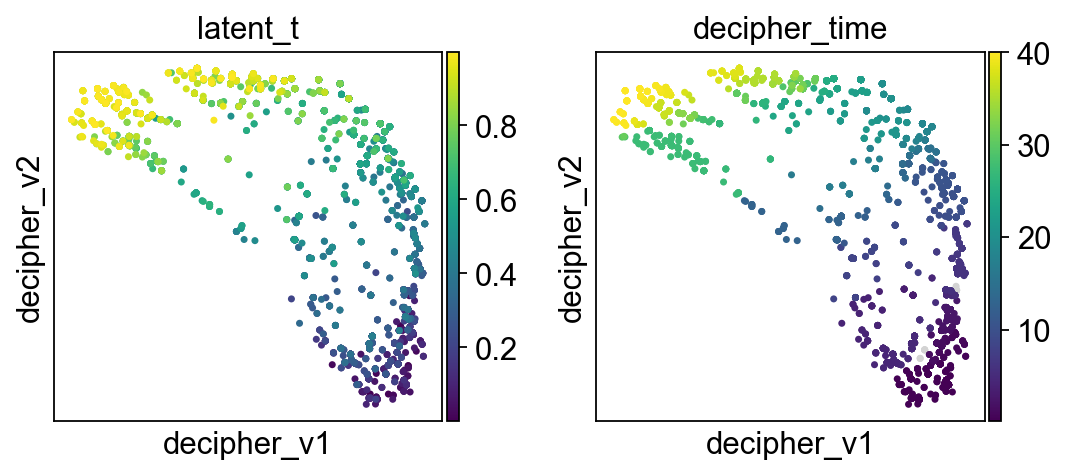

Base Decipher, sigma=0.1, seed=0, rho = 0.9402


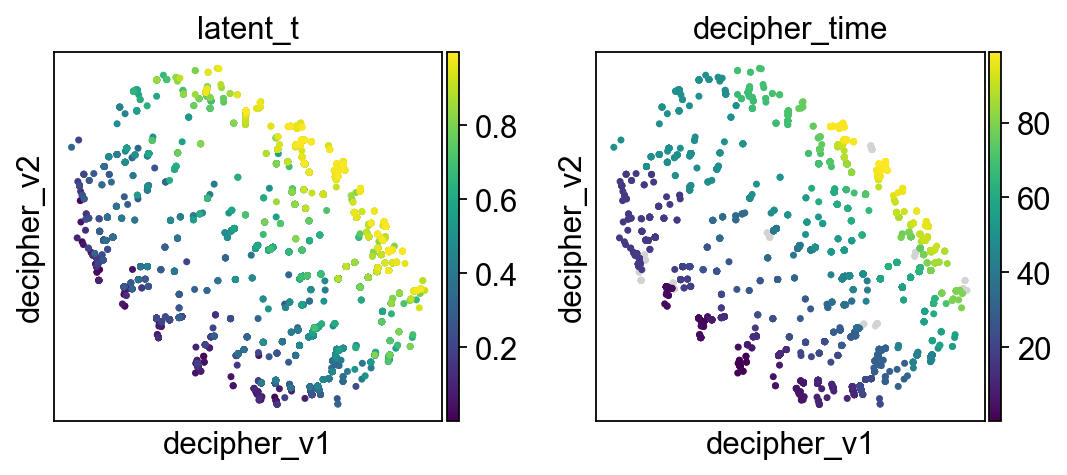

Decipher-BC, sigma=0.1, seed=0, rho = 0.9331


In [10]:
sigma = 0.1
row_base, adata_base = load_run(results_df, sigma, "Base Decipher")
row_bc, adata_bc = load_run(results_df, sigma, "Decipher-BC")

sc.pl.embedding(adata_base, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Base Decipher, sigma={sigma}, seed={row_base['seed']}, rho = {row_base['rho']:.4f}")

sc.pl.embedding(adata_bc, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Decipher-BC, sigma={sigma}, seed={row_bc['seed']}, rho = {row_bc['rho']:.4f}")

Base Decipher  sigma=0.1  ground truth z silhouette (by batch) = -0.0343
Base Decipher  sigma=0.1  learned decipher_z silhouette (by batch) = -0.0466


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


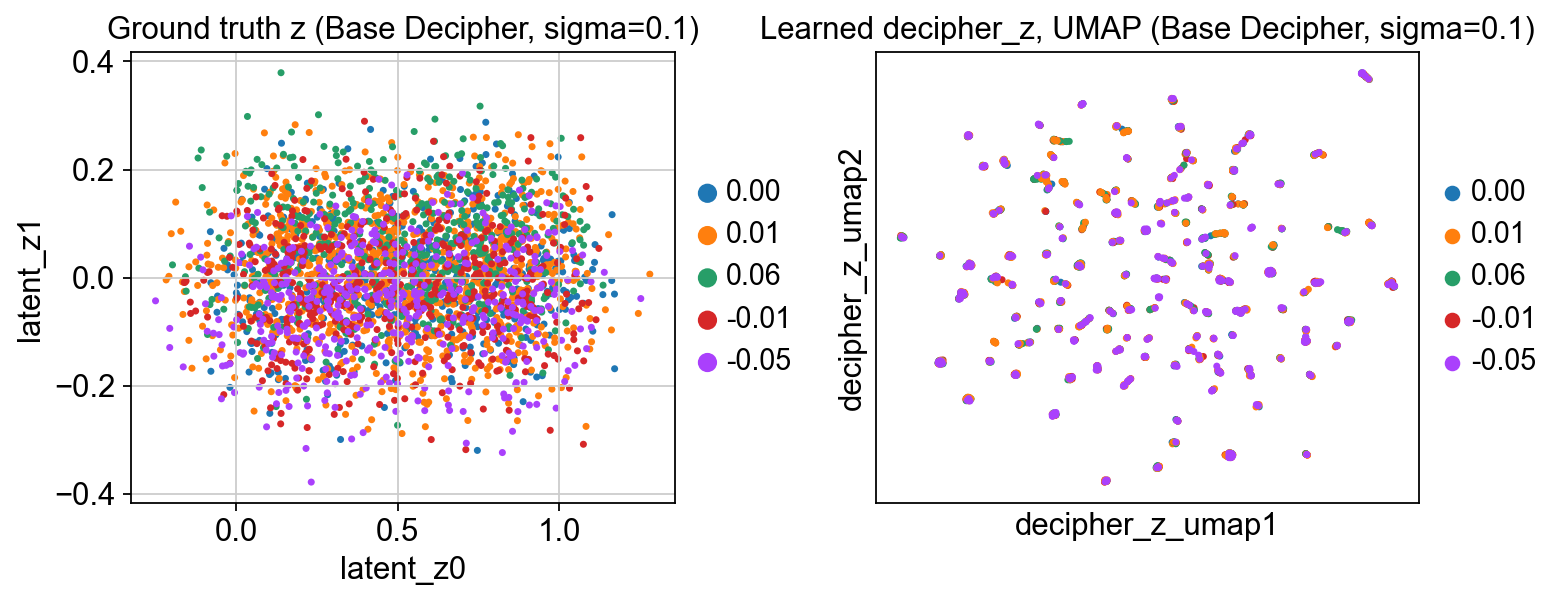

Decipher-BC  sigma=0.1  ground truth z silhouette (by batch) = -0.0343
Decipher-BC  sigma=0.1  learned decipher_z silhouette (by batch) = -0.0554


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


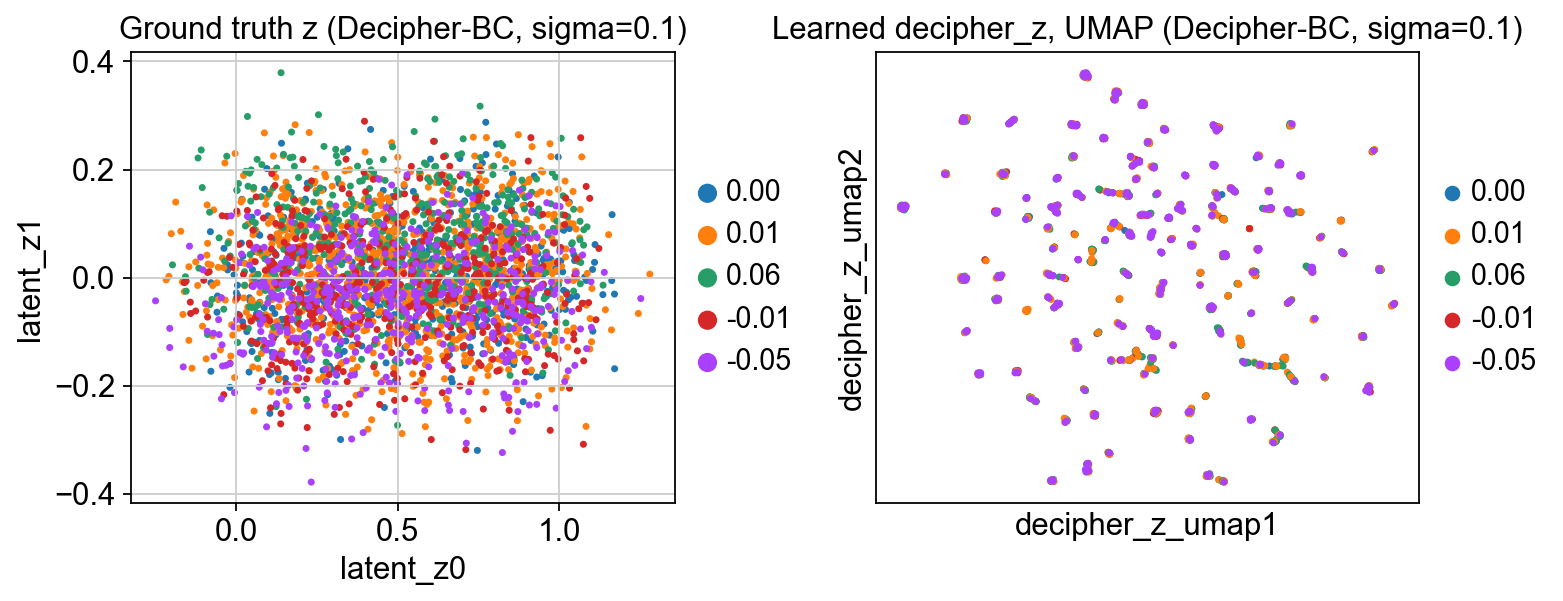

In [11]:
for model_name, adata, row in [("Base Decipher", adata_base, row_base), ("Decipher-BC", adata_bc, row_bc)]:
    batch_labels = adata.obs["batch"].astype(str)

    sil_ground_truth = silhouette_score(
        adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    sil_learned = silhouette_score(
        adata.obsm["decipher_z"], batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    print(f"{model_name}  sigma={sigma}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
    print(f"{model_name}  sigma={sigma}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

    sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
    sc.tl.umap(adata, random_state=42)
    adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
                  ax=axes[0], show=False, title=f"Ground truth z ({model_name}, sigma={sigma})")
    sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                    ax=axes[1], show=False, title=f"Learned decipher_z, UMAP ({model_name}, sigma={sigma})")
    plt.tight_layout()
    plt.show()


## Plots for Sigma = 1.0
Specifically, we look at
- Learned vs latent pseudotime
- Learned vs latent ground truth

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


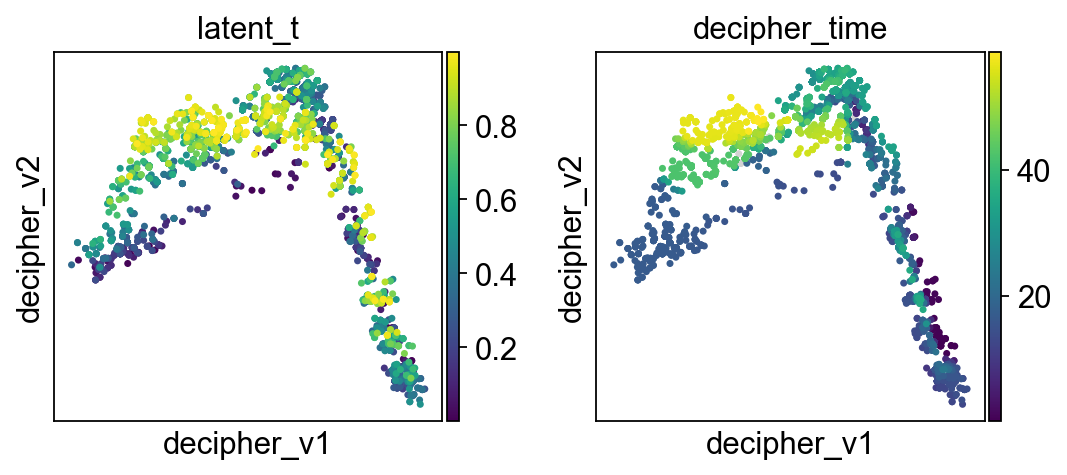

Base Decipher, sigma=1.0, seed=0, rho = 0.5349


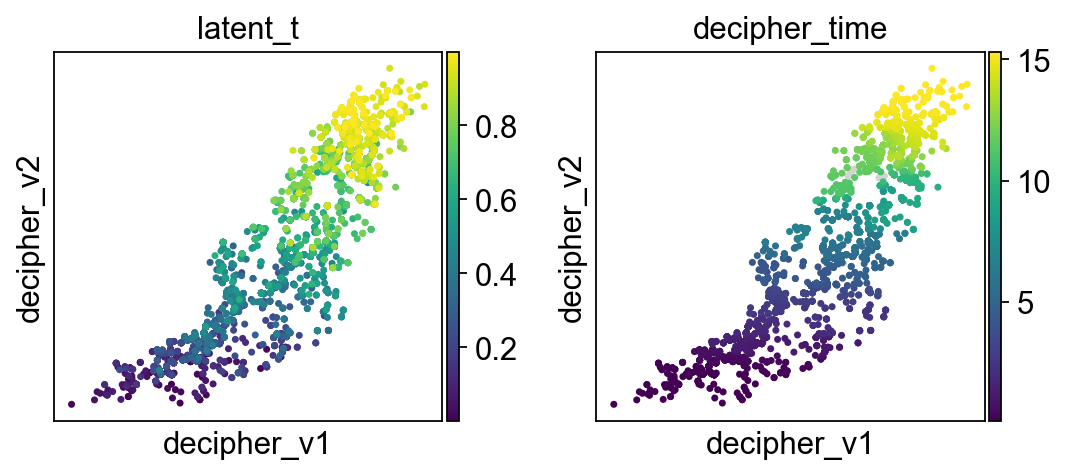

Decipher-BC, sigma=1.0, seed=0, rho = 0.9369


In [13]:
sigma = 1.0
row_base, adata_base = load_run(results_df, sigma, "Base Decipher")
row_bc, adata_bc = load_run(results_df, sigma, "Decipher-BC")

sc.pl.embedding(adata_base, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Base Decipher, sigma={sigma}, seed={row_base['seed']}, rho = {row_base['rho']:.4f}")

sc.pl.embedding(adata_bc, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Decipher-BC, sigma={sigma}, seed={row_bc['seed']}, rho = {row_bc['rho']:.4f}")

Base Decipher  sigma=1.0  ground truth z silhouette (by batch) = 0.1160
Base Decipher  sigma=1.0  learned decipher_z silhouette (by batch) = 0.1480


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


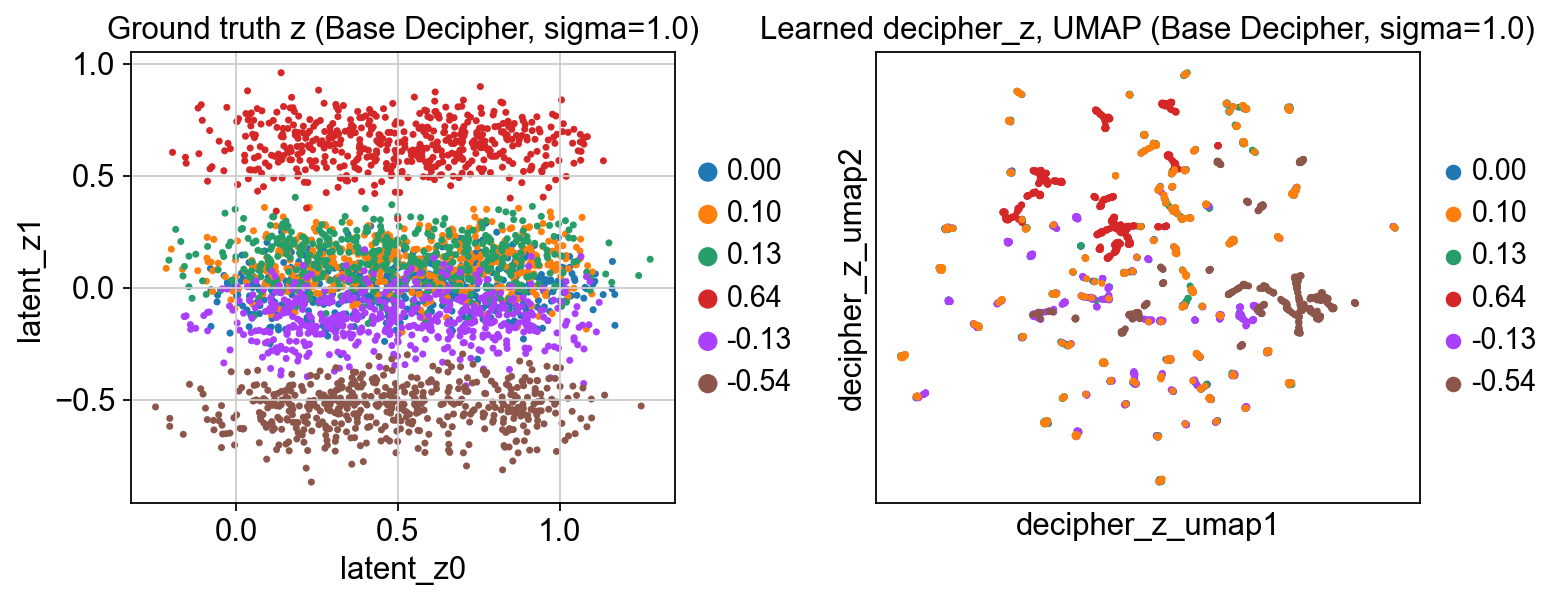

Decipher-BC  sigma=1.0  ground truth z silhouette (by batch) = 0.1160
Decipher-BC  sigma=1.0  learned decipher_z silhouette (by batch) = 0.1175


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


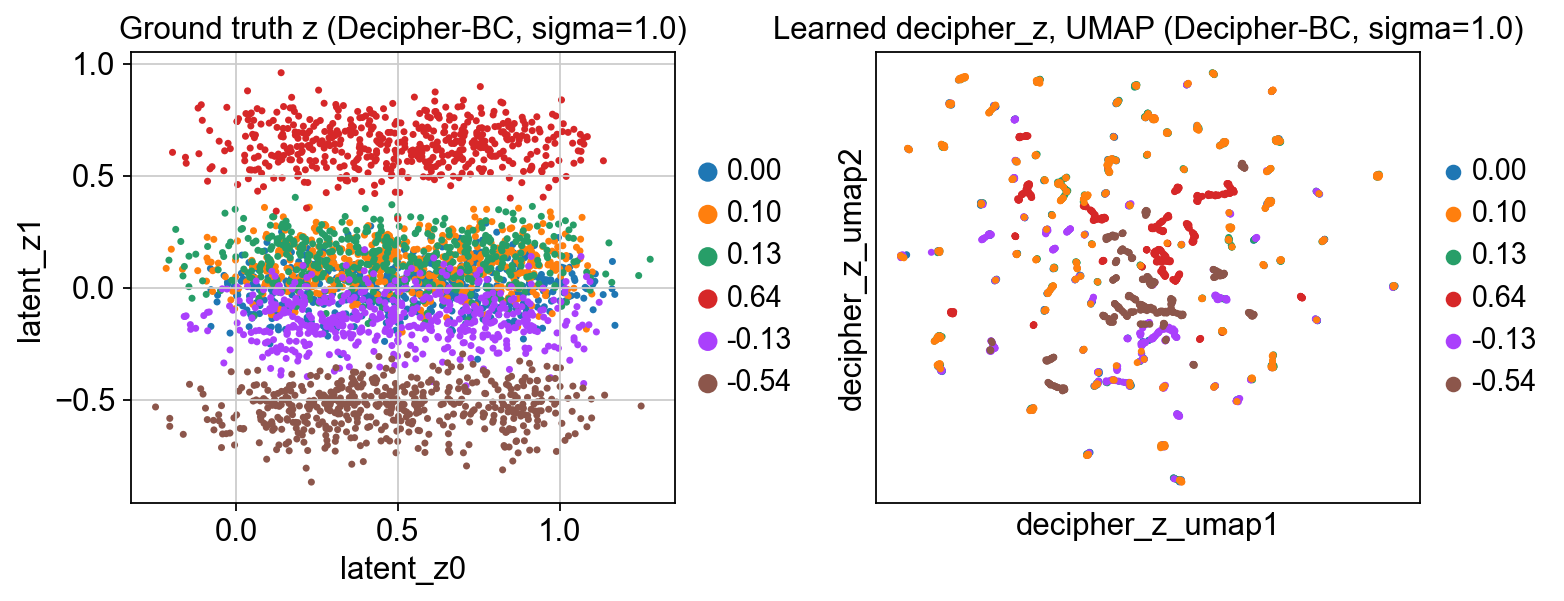

In [14]:
for model_name, adata, row in [("Base Decipher", adata_base, row_base), ("Decipher-BC", adata_bc, row_bc)]:
    batch_labels = adata.obs["batch"].astype(str)

    sil_ground_truth = silhouette_score(
        adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    sil_learned = silhouette_score(
        adata.obsm["decipher_z"], batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    print(f"{model_name}  sigma={sigma}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
    print(f"{model_name}  sigma={sigma}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

    sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
    sc.tl.umap(adata, random_state=42)
    adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
                  ax=axes[0], show=False, title=f"Ground truth z ({model_name}, sigma={sigma})")
    sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                    ax=axes[1], show=False, title=f"Learned decipher_z, UMAP ({model_name}, sigma={sigma})")
    plt.tight_layout()
    plt.show()

## Plots for Sigma = 5.0
Specifically, we look at
- Learned vs latent pseudotime
- Learned vs latent ground truth

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


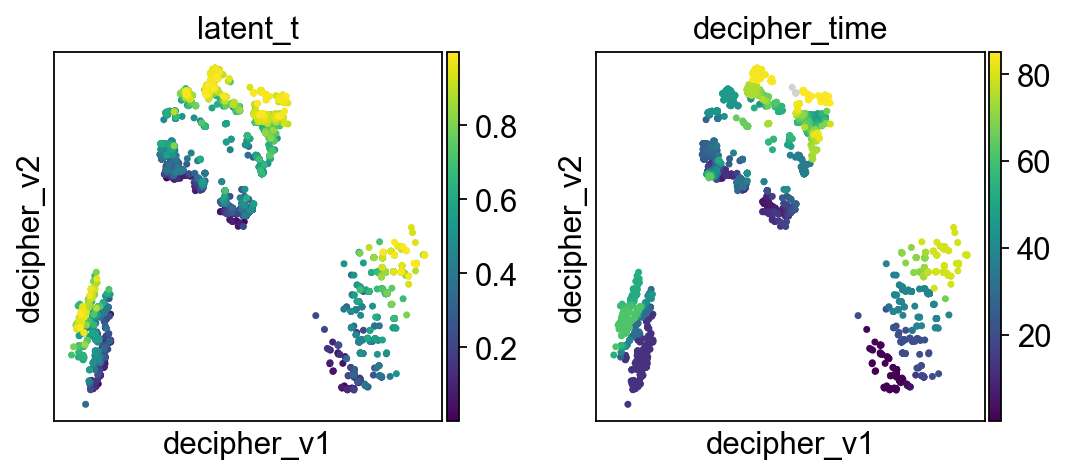

Base Decipher, sigma=5.0, seed=0, rho = 0.8337


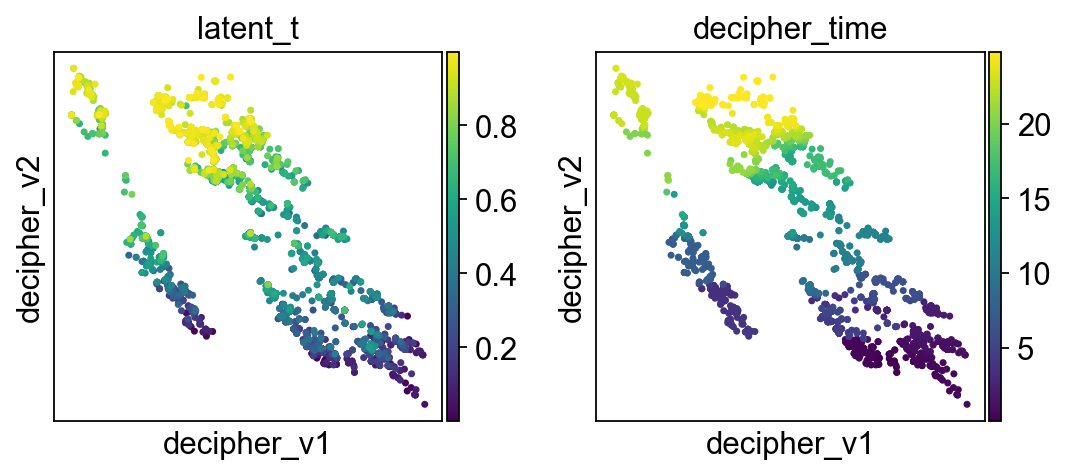

Decipher-BC, sigma=5.0, seed=0, rho = 0.9183


In [15]:
sigma = 5.0
row_base, adata_base = load_run(results_df, sigma, "Base Decipher")
row_bc, adata_bc = load_run(results_df, sigma, "Decipher-BC")

sc.pl.embedding(adata_base, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Base Decipher, sigma={sigma}, seed={row_base['seed']}, rho = {row_base['rho']:.4f}")

sc.pl.embedding(adata_bc, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Decipher-BC, sigma={sigma}, seed={row_bc['seed']}, rho = {row_bc['rho']:.4f}")

Base Decipher  sigma=5.0  ground truth z silhouette (by batch) = 0.4381
Base Decipher  sigma=5.0  learned decipher_z silhouette (by batch) = 0.3061


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


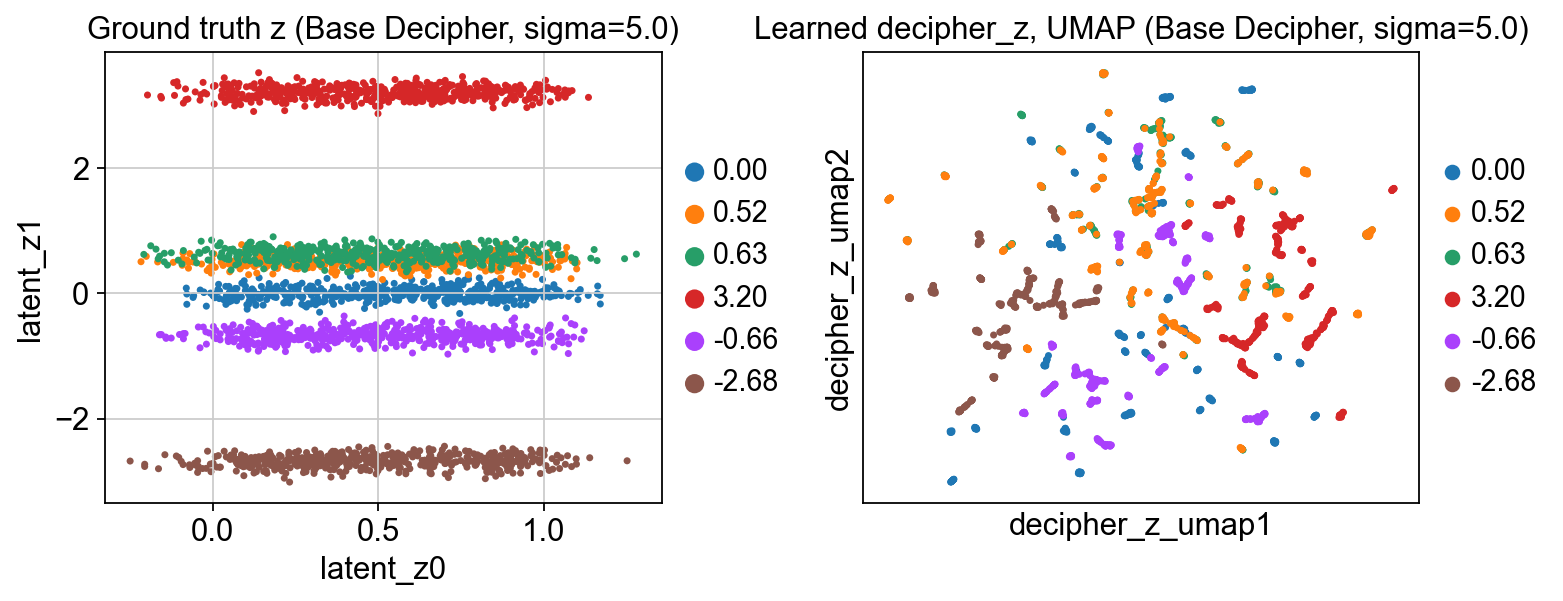

Decipher-BC  sigma=5.0  ground truth z silhouette (by batch) = 0.4381
Decipher-BC  sigma=5.0  learned decipher_z silhouette (by batch) = 0.2475


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


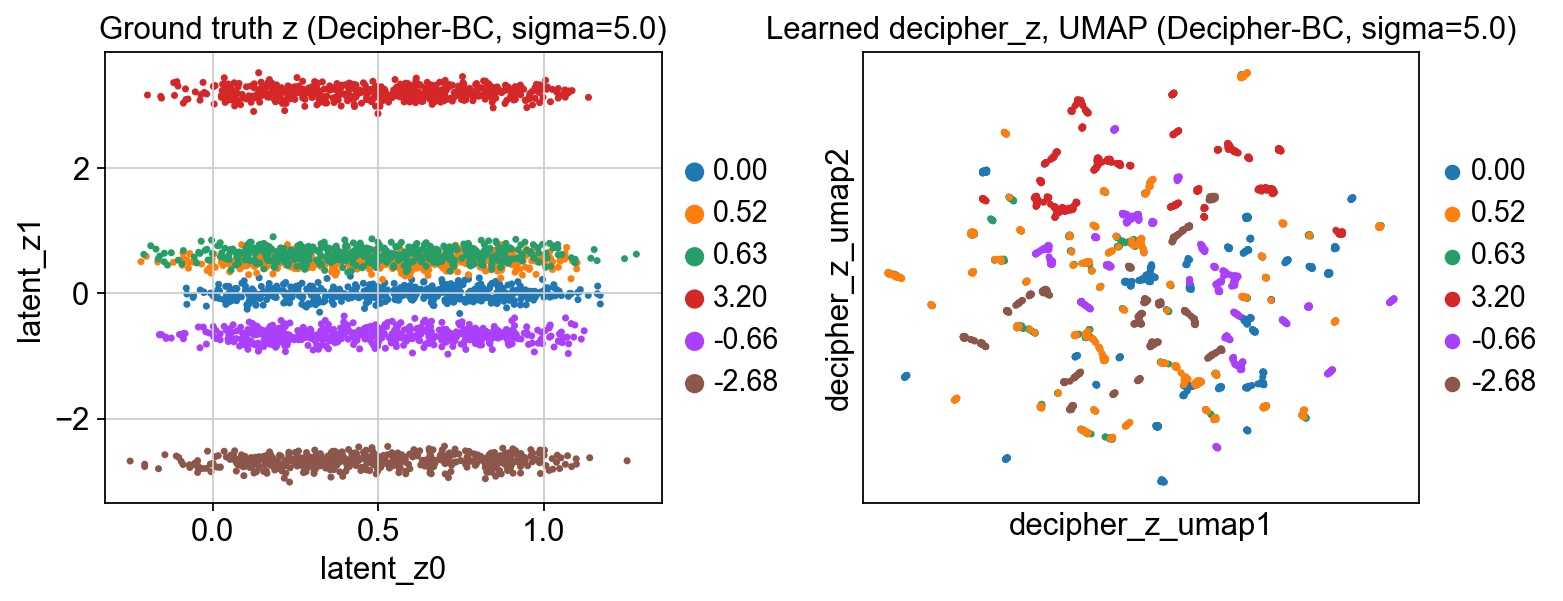

In [16]:
for model_name, adata, row in [("Base Decipher", adata_base, row_base), ("Decipher-BC", adata_bc, row_bc)]:
    batch_labels = adata.obs["batch"].astype(str)

    sil_ground_truth = silhouette_score(
        adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    sil_learned = silhouette_score(
        adata.obsm["decipher_z"], batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    print(f"{model_name}  sigma={sigma}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
    print(f"{model_name}  sigma={sigma}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

    sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
    sc.tl.umap(adata, random_state=42)
    adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
                  ax=axes[0], show=False, title=f"Ground truth z ({model_name}, sigma={sigma})")
    sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                    ax=axes[1], show=False, title=f"Learned decipher_z, UMAP ({model_name}, sigma={sigma})")
    plt.tight_layout()
    plt.show()


## Plots for Sigma = 10.0
Specifically, we look at
- Learned vs latent pseudotime
- Learned vs latent ground truth

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


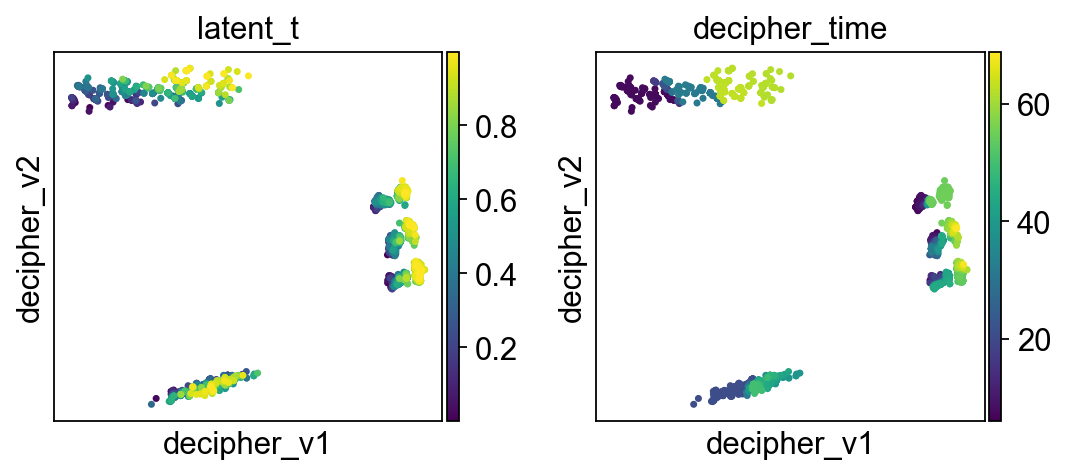

Base Decipher, sigma=10.0, seed=0, rho = 0.7773


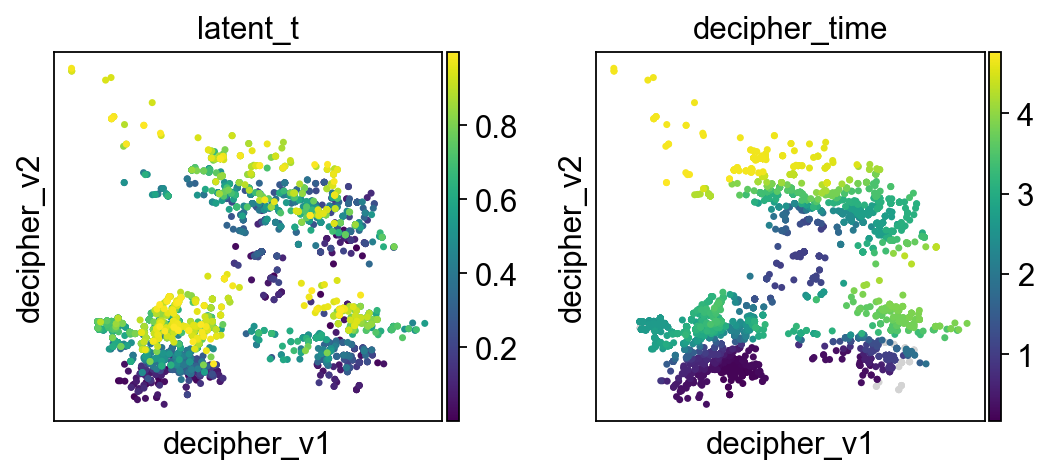

Decipher-BC, sigma=10.0, seed=0, rho = 0.5669


In [17]:
sigma = 10.0
row_base, adata_base = load_run(results_df, sigma, "Base Decipher")
row_bc, adata_bc = load_run(results_df, sigma, "Decipher-BC")

sc.pl.embedding(adata_base, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Base Decipher, sigma={sigma}, seed={row_base['seed']}, rho = {row_base['rho']:.4f}")

sc.pl.embedding(adata_bc, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"Decipher-BC, sigma={sigma}, seed={row_bc['seed']}, rho = {row_bc['rho']:.4f}")

Base Decipher  sigma=10.0  ground truth z silhouette (by batch) = 0.5730
Base Decipher  sigma=10.0  learned decipher_z silhouette (by batch) = 0.5220


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


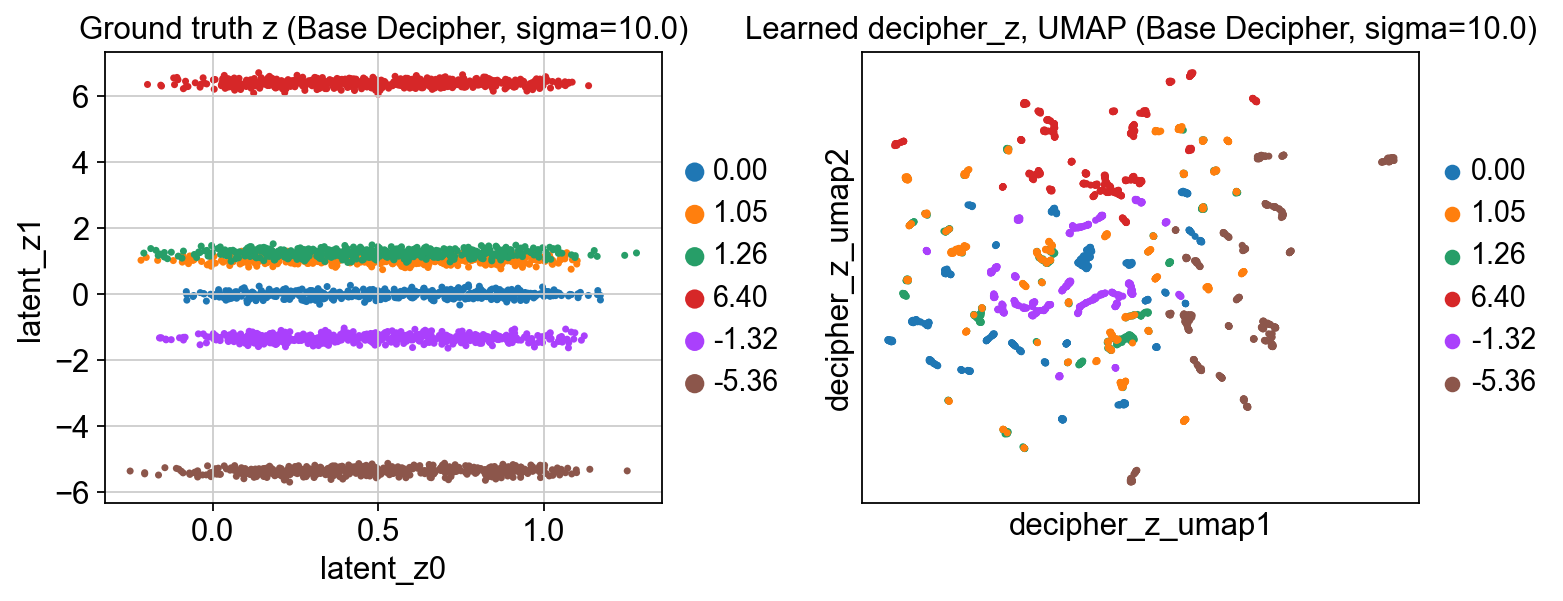

Decipher-BC  sigma=10.0  ground truth z silhouette (by batch) = 0.5730
Decipher-BC  sigma=10.0  learned decipher_z silhouette (by batch) = 0.6376


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


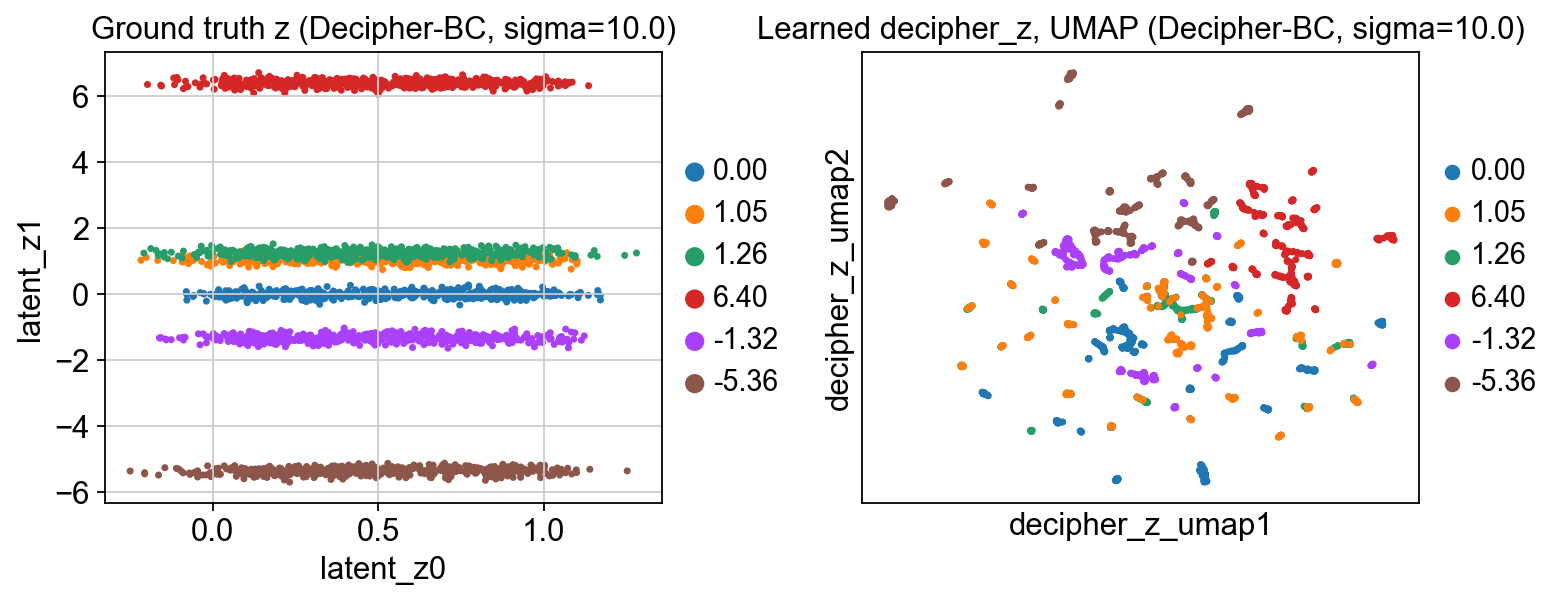

In [18]:
for model_name, adata, row in [("Base Decipher", adata_base, row_base), ("Decipher-BC", adata_bc, row_bc)]:
    batch_labels = adata.obs["batch"].astype(str)

    sil_ground_truth = silhouette_score(
        adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    sil_learned = silhouette_score(
        adata.obsm["decipher_z"], batch_labels,
        sample_size=min(5000, adata.n_obs), random_state=42,
    )
    print(f"{model_name}  sigma={sigma}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
    print(f"{model_name}  sigma={sigma}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

    sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
    sc.tl.umap(adata, random_state=42)
    adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
                  ax=axes[0], show=False, title=f"Ground truth z ({model_name}, sigma={sigma})")
    sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                    ax=axes[1], show=False, title=f"Learned decipher_z, UMAP ({model_name}, sigma={sigma})")
    plt.tight_layout()
    plt.show()
